<a href="https://colab.research.google.com/github/iyadgantengg120-oss/machine-learning/blob/main/ml_p2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyswarms --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import pyswarms as ps

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Jumlah data train:", train.shape)
print("Jumlah data test :", test.shape)
print(train["Activity"].value_counts())

Jumlah data train: (1278, 563)
Jumlah data test : (2947, 563)
Activity
WALKING               266
STANDING              227
LAYING                221
SITTING               198
WALKING_UPSTAIRS      185
WALKING_DOWNSTAIRS    180
Name: count, dtype: int64


In [ ]:
drop_cols = [c for c in ["Activity", "subject"] if c in train.columns]

X_train = train.drop(columns=drop_cols)
y_train = train["Activity"]

X_test = test.drop(columns=drop_cols)
y_test = test["Activity"]

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Kelas aktivitas:", list(le.classes_))

Kelas aktivitas: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


In [ ]:
print("Jumlah NaN di X_train:", X_train.isnull().sum().sum())
print("Jumlah NaN di X_test :", X_test.isnull().sum().sum())

# Isi nilai kosong dengan rata-rata kolom
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

print("Setelah dibersihkan -> NaN di X_train:", X_train.isnull().sum().sum())
print("Setelah dibersihkan -> NaN di X_test :", X_test.isnull().sum().sum())

Jumlah NaN di X_train: 0
Jumlah NaN di X_test : 0
Setelah dibersihkan -> NaN di X_train: 0
Setelah dibersihkan -> NaN di X_test : 0


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm_baseline = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_baseline.fit(X_train_scaled, y_train_enc)

y_pred_baseline = svm_baseline.predict(X_test_scaled)
acc_baseline = accuracy_score(y_test_enc, y_pred_baseline)

print("\n=== HASIL SVM BASELINE (tanpa optimasi) ===")
print(f"Akurasi: {acc_baseline * 100:.2f}%")
print(classification_report(y_test_enc, y_pred_baseline, target_names=le.classes_))


=== HASIL SVM BASELINE (tanpa optimasi) ===
Akurasi: 87.55%
                    precision    recall  f1-score   support

            LAYING       1.00      0.98      0.99       537
           SITTING       0.95      0.67      0.78       491
          STANDING       0.75      0.96      0.84       532
           WALKING       0.98      0.86      0.92       496
WALKING_DOWNSTAIRS       0.76      0.88      0.82       420
  WALKING_UPSTAIRS       0.89      0.88      0.89       471

          accuracy                           0.88      2947
         macro avg       0.89      0.87      0.87      2947
      weighted avg       0.89      0.88      0.88      2947



In [ ]:
def svm_fitness(params):
    n_particles = params.shape[0]
    fitness_values = np.zeros(n_particles)

    for i in range(n_particles):
        C_val = params[i, 0]
        gamma_val = params[i, 1]

        C_val = max(C_val, 0.001)
        gamma_val = max(gamma_val, 0.0001)

        model = SVC(kernel="rbf", C=C_val, gamma=gamma_val)
        model.fit(X_train_scaled, y_train_enc)
        pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test_enc, pred)

        fitness_values[i] = 1 - acc

    return fitness_values

In [ ]:
bounds = (np.array([0.1, 0.0001]), np.array([100, 1]))
options = {"c1": 0.5, "c2": 0.3, "w": 0.9}

optimizer = ps.single.GlobalBestPSO(
    n_particles=10,
    dimensions=2,
    options=options,
    bounds=bounds,
)

best_cost, best_pos = optimizer.optimize(svm_fitness, iters=20)

best_C, best_gamma = best_pos
print(f"\nParameter terbaik hasil PSO -> C: {best_C:.4f}, gamma: {best_gamma:.4f}")
print(f"Estimasi akurasi terbaik selama optimasi: {(1 - best_cost) * 100:.2f}%")

2026-09-12 04:42:07,033 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|20/20, best_cost=0.117
2026-09-12 04:53:09,660 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.1174075330844927, best pos: [5.92176432e+01 1.17346734e-03]



Parameter terbaik hasil PSO -> C: 59.2176, gamma: 0.0012
Estimasi akurasi terbaik selama optimasi: 88.26%


In [ ]:
svm_optimized = SVC(kernel="rbf", C=best_C, gamma=best_gamma)
svm_optimized.fit(X_train_scaled, y_train_enc)

y_pred_optimized = svm_optimized.predict(X_test_scaled)
acc_optimized = accuracy_score(y_test_enc, y_pred_optimized)

print("\n=== HASIL SVM + PSO (setelah optimasi) ===")
print(f"Akurasi: {acc_optimized * 100:.2f}%")
print(classification_report(y_test_enc, y_pred_optimized, target_names=le.classes_))


=== HASIL SVM + PSO (setelah optimasi) ===
Akurasi: 88.26%
                    precision    recall  f1-score   support

            LAYING       0.99      0.97      0.98       537
           SITTING       0.90      0.75      0.82       491
          STANDING       0.79      0.93      0.85       532
           WALKING       0.97      0.91      0.94       496
WALKING_DOWNSTAIRS       0.79      0.84      0.82       420
  WALKING_UPSTAIRS       0.87      0.88      0.87       471

          accuracy                           0.88      2947
         macro avg       0.89      0.88      0.88      2947
      weighted avg       0.89      0.88      0.88      2947




=== PERBANDINGAN HASIL ===
SVM Baseline (default) : 87.55%
SVM + PSO (optimized)  : 88.26%
Peningkatan akurasi    : 0.71%


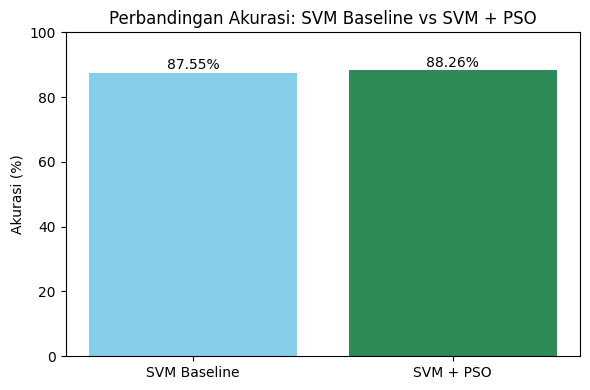

In [ ]:
print("\n=== PERBANDINGAN HASIL ===")
print(f"SVM Baseline (default) : {acc_baseline * 100:.2f}%")
print(f"SVM + PSO (optimized)  : {acc_optimized * 100:.2f}%")
print(f"Peningkatan akurasi    : {(acc_optimized - acc_baseline) * 100:.2f}%")

comparison_df = pd.DataFrame(
    {
        "Model": ["SVM Baseline", "SVM + PSO"],
        "Akurasi (%)": [acc_baseline * 100, acc_optimized * 100],
    }
)

plt.figure(figsize=(6, 4))
plt.bar(comparison_df["Model"], comparison_df["Akurasi (%)"], color=["skyblue", "seagreen"])
plt.title("Perbandingan Akurasi: SVM Baseline vs SVM + PSO")
plt.ylabel("Akurasi (%)")
plt.ylim(0, 100)
for i, v in enumerate(comparison_df["Akurasi (%)"]):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")
plt.tight_layout()
plt.show()

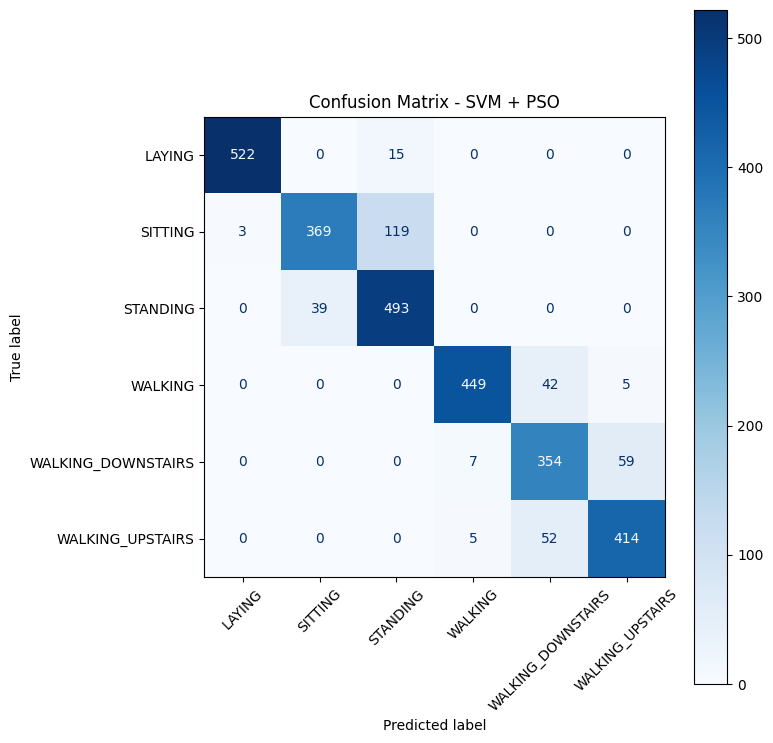

In [ ]:
cm = confusion_matrix(y_test_enc, y_pred_optimized)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - SVM + PSO")
plt.tight_layout()
plt.show()